
# Image Classification using CNN with TensorFlow

## Problem Definition

The objective of this project is to build a **Convolutional Neural Network (CNN)**
for image classification using TensorFlow and Keras.

The model will:
- Load and preprocess image data
- Build a CNN architecture
- Train the CNN model
- Evaluate model performance
- Visualize accuracy and loss graphs
- Predict image classes

### Deep Learning Framework Used
- TensorFlow
- Keras

### Dataset Used
- CIFAR-10 Dataset

### Evaluation Metrics
- Accuracy
- Loss


In [1]:

# Import Required Libraries

import tensorflow as tf
from tensorflow.keras import datasets, layers, models

import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [2]:

# Load CIFAR-10 Dataset

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 69s 0us/step 
Training Data Shape: (50000, 32, 32, 3)
Testing Data Shape: (10000, 32, 32, 3)


In [3]:

# Define Class Names

class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

print(class_names)


['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


In [4]:

# Normalize Image Pixel Values

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalization Completed.")


Normalization Completed.


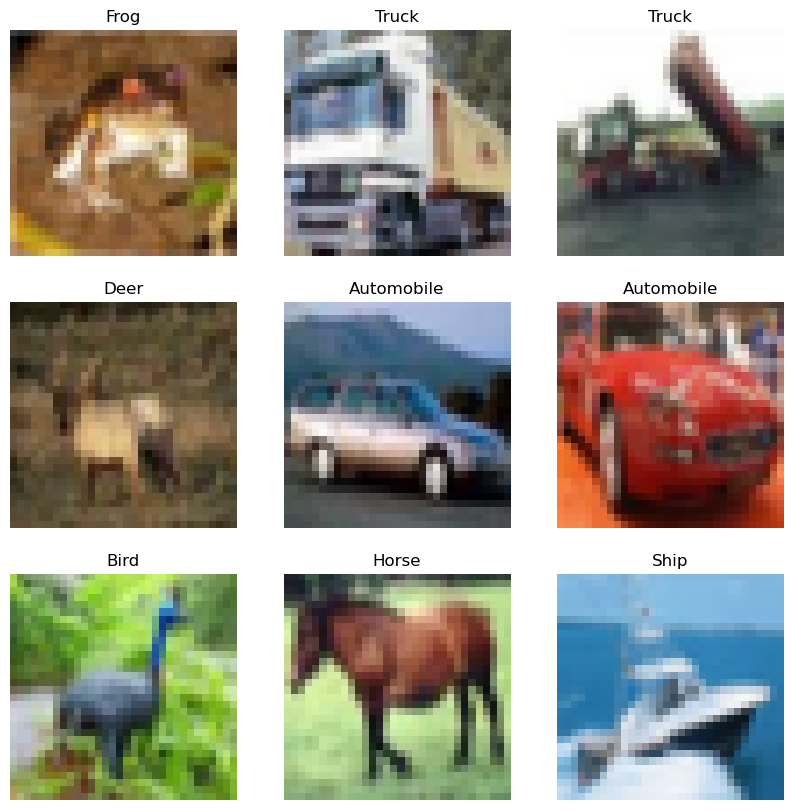

In [5]:

# Display Sample Images

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis('off')

plt.show()


In [6]:

# Build CNN Model

model = models.Sequential()

# Convolution Layer 1
model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))

model.add(layers.MaxPooling2D((2,2)))

# Convolution Layer 2
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))

# Convolution Layer 3
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

print("CNN Model Built Successfully.")


CNN Model Built Successfully.


In [7]:

# Display Model Summary

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:

# Compile CNN Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully.")


Model Compiled Successfully.


In [9]:

# Train CNN Model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.4379 - loss: 1.5442 - val_accuracy: 0.5433 - val_loss: 1.2706
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 46ms/step - accuracy: 0.5826 - loss: 1.1736 - val_accuracy: 0.6018 - val_loss: 1.1291
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6438 - loss: 1.0067 - val_accuracy: 0.6373 - val_loss: 1.0187
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.6805 - loss: 0.9035 - val_accuracy: 0.6791 - val_loss: 0.9121
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.7115 - loss: 0.8305 - val_accuracy: 0.6951 - val_loss: 0.8782
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.7298 - loss: 0.7667 - val_accuracy: 0.6974 - val_loss: 0.8930
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.7488 - loss: 0.7164 - val_accuracy: 0.7078 - val_loss: 0.8651
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 47ms/step - accuracy: 0.7676 -

In [10]:

# Evaluate CNN Model

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy :", test_accuracy)
print("Test Loss     :", test_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7063 - loss: 0.8826
Test Accuracy : 0.7063000202178955
Test Loss     : 0.882561445236206


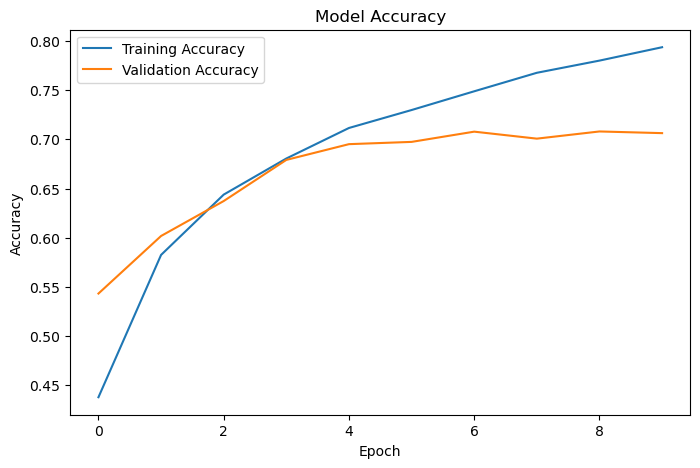

In [11]:

# Plot Training and Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()


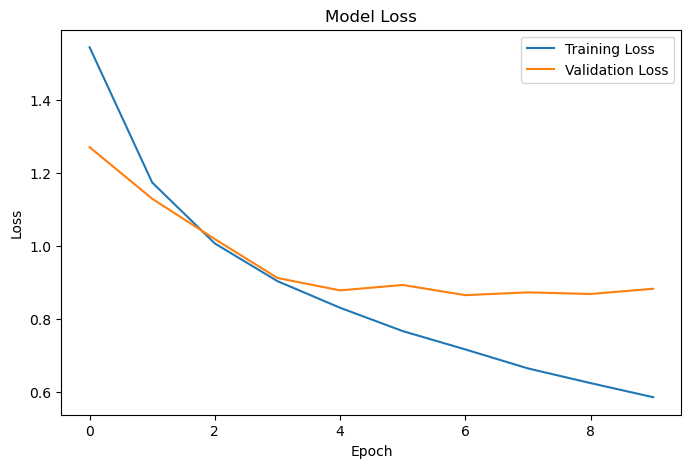

In [12]:

# Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()


In [13]:

# Make Predictions

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print("Predicted Classes:")
print(predicted_classes[:10])


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
Predicted Classes:
[3 8 8 0 4 6 1 6 3 1]


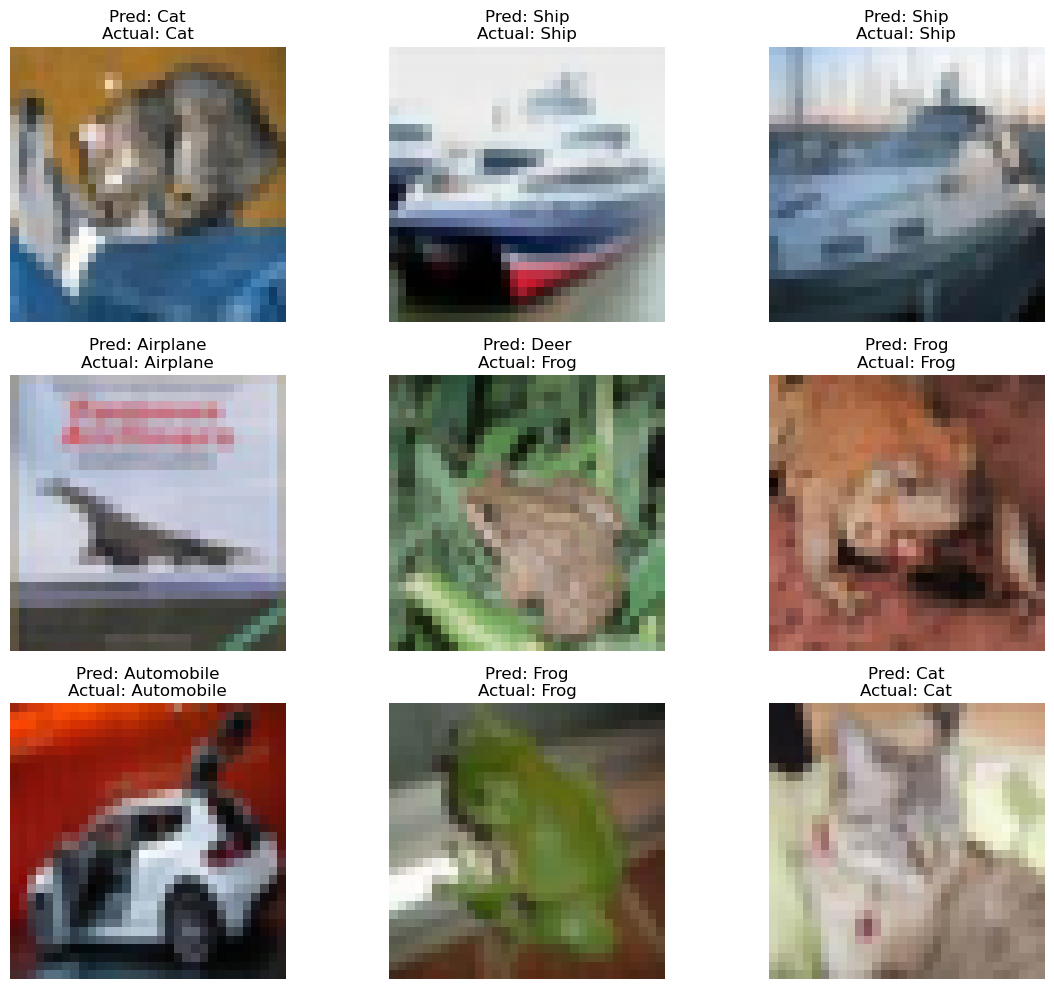

In [14]:

# Visualize Predictions

plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    predicted_label = class_names[predicted_classes[i]]

    actual_label = class_names[y_test[i][0]]

    plt.title(f"Pred: {predicted_label}\nActual: {actual_label}")

    plt.axis('off')

plt.tight_layout()

plt.show()



# Model Analysis

## Observations

- The CNN model successfully learned image features.
- Accuracy improved over training epochs.
- Validation accuracy indicates model generalization capability.

## Advantages of CNN

- Automatically extracts image features
- Highly effective for image classification
- Handles complex image patterns

## Challenges

- Requires significant computational power
- Training time can be high
- Risk of overfitting on small datasets

## Possible Improvements

- Data augmentation
- Transfer learning
- Hyperparameter tuning
- Deeper CNN architectures



# Conclusion

In this project:

- A CNN-based image classification model was built using TensorFlow.
- The CIFAR-10 dataset was used for training and testing.
- Image preprocessing and normalization were performed.
- The model was trained and evaluated successfully.
- Accuracy and loss graphs were visualized.
- Predictions were generated on test images.

Convolutional Neural Networks are powerful deep learning models
widely used in computer vision applications.
